## Modelo S com adam optimizer

In [4]:
# dependencies
from keras.utils import image_dataset_from_directory
from tensorflow import keras
from keras import layers
import matplotlib.pyplot as plt
from keras import layers, regularizers
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.preprocessing import image
import numpy as np

In [5]:
train_dir = 'train'
validation_dir = 'validation'
test_dir = 'test'

IMG_SIZE = 32

train_dataset = image_dataset_from_directory(train_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=32) 
validation_dataset = image_dataset_from_directory(validation_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=32)
test_dataset = image_dataset_from_directory(test_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=32)

Found 40000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


In [6]:
data_augmentation = keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.2),
])

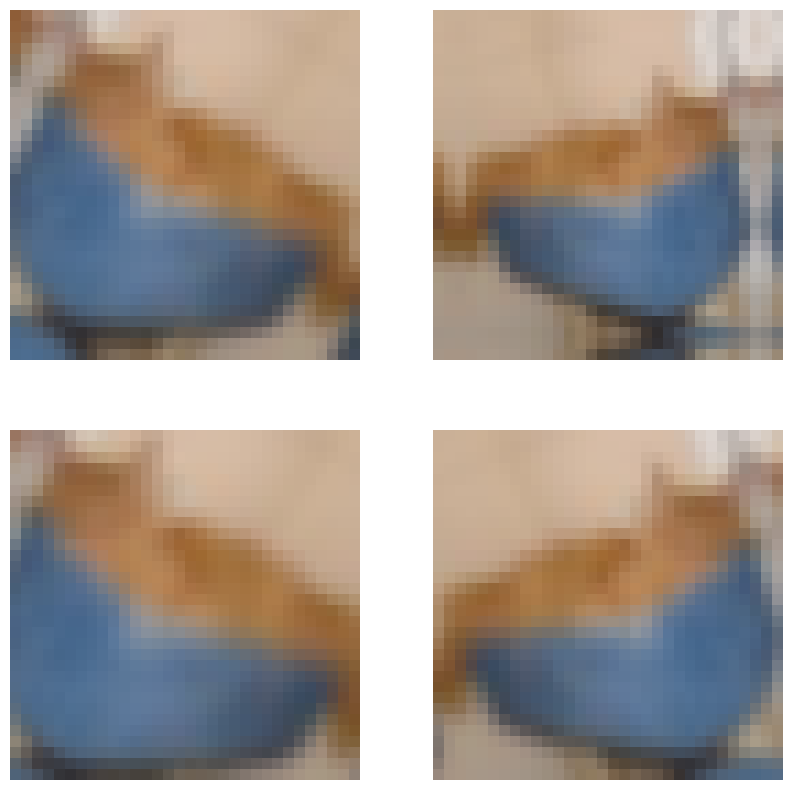

In [7]:
# apresentar 4 primeiras imagens da primeira batch
plt.figure(figsize=(10, 10))
for images, _ in train_dataset.take(1):
  for i in range(4):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(2, 2, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

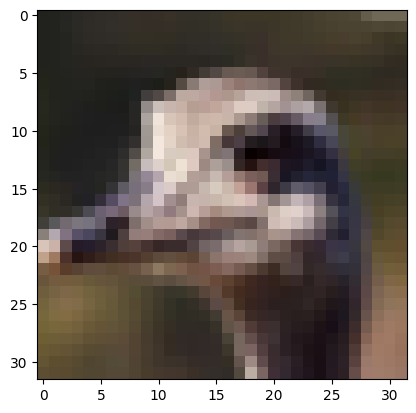

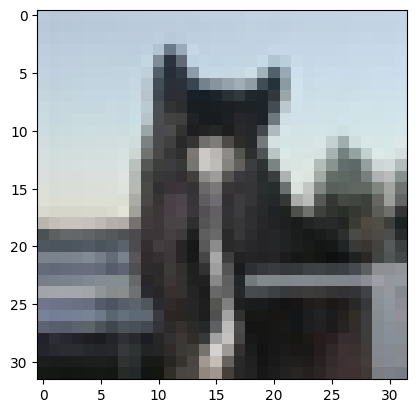

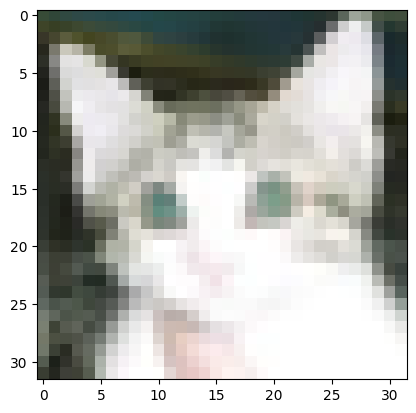

In [8]:
# import matplotlib.pyplot as plt

for data_batch, _ in train_dataset.take(1):
  for i in range(3):
    plt.imshow(data_batch[i].numpy().astype("uint8"))
    plt.show()

In [9]:
inputs = keras.Input(shape=(32, 32, 3))
x = data_augmentation(inputs)

l2_regularizer = 0.001

x = layers.Conv2D(filters=50, kernel_size=3, activation="relu")(inputs)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=100, kernel_size=3, activation="relu", kernel_regularizer=regularizers.L2(l2_regularizer))(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Dropout(0.25)(x)

x = layers.Conv2D(filters=100, kernel_size=3, activation="relu", kernel_regularizer=regularizers.L2(l2_regularizer))(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Flatten()(x)

x = layers.Dropout(0.5)(x)
x = layers.Dense(100, activation="relu")(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(25, activation="relu")(x)
outputs = layers.Dense(10, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 100)    │        45,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 100)      │        90,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        40,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         2,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 179,485 (701.11 KB)

 Trainable params: 179,485 (701.11 KB)

 Non-trainable params: 0 (0.00 B)

Como teste, foi utilizado o otimizador "Adam". A grande diferença em relação ao otimizador RMSprop é que o Adam calcula a learning rate de forma adaptativa com base nas estimativas das médias e variâncias dos gradientes. 

In [10]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc'])

In [16]:
model_filename = 'model_s_sem_optuna_adam.keras'

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# para salvar o melhor modelo
checkpoint_callback = ModelCheckpoint(
    model_filename,
    monitor='val_acc', 
    save_best_only=True,
    mode='max',
    save_weights_only=False
)

# Training the model
history = model.fit(train_dataset, epochs=100, validation_data=validation_dataset, callbacks=[early_stopping, checkpoint_callback])


Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - acc: 0.6279 - loss: 1.2021 - val_acc: 0.6937 - val_loss: 1.0552
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - acc: 0.6355 - loss: 1.1809 - val_acc: 0.6969 - val_loss: 1.0647
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - acc: 0.6381 - loss: 1.1813 - val_acc: 0.6673 - val_loss: 1.1475
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - acc: 0.6353 - loss: 1.1915 - val_acc: 0.6724 - val_loss: 1.1079
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - acc: 0.6344 - loss: 1.1993 - val_acc: 0.6518 - val_loss: 1.1616
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - acc: 0.6363 - loss: 1.1913 - val_acc: 0.6668 - val_loss: 1.1083
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 27ms/step - acc: 0.6368 - loss: 1.1941 - val_acc: 0.6787 - val_loss: 1.0773
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - acc: 0.6356 - loss: 1.1879 - val_acc: 0.6814 - val_loss: 1.0849
Epoch 9/100
1250

O 1º treino terminou bastante cedo pois o early stopping foi implementado e por 10 épocas não houve melhoria da accuracy de validação.
Por análise do gráfico entende-se que a accuracy de validação foi sempre superior à accuracy de treino, o que é um bom sinal, no entanto o treino parou.
Decidimos então forçar a continuação do treino, resultando o output apresentado em cima. Ou seja, embora parecesse que o modelo estava a convergir, a accuracy de validação não melhorou e o treino foi interrompido.

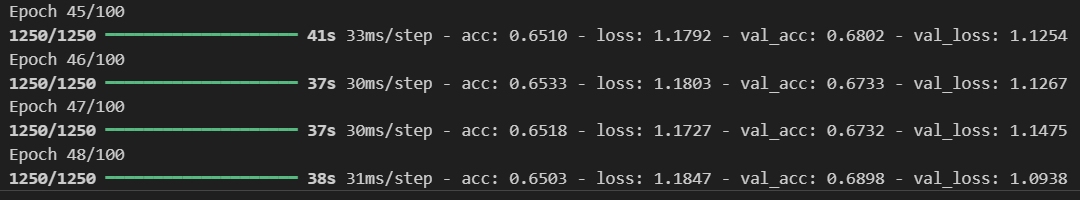

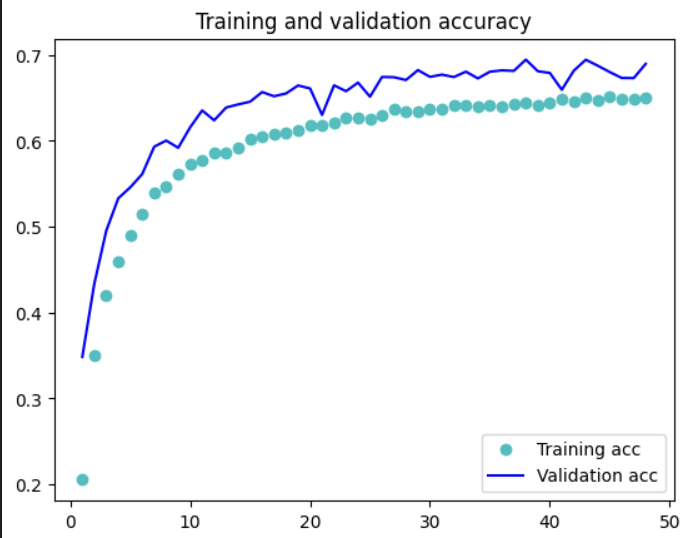

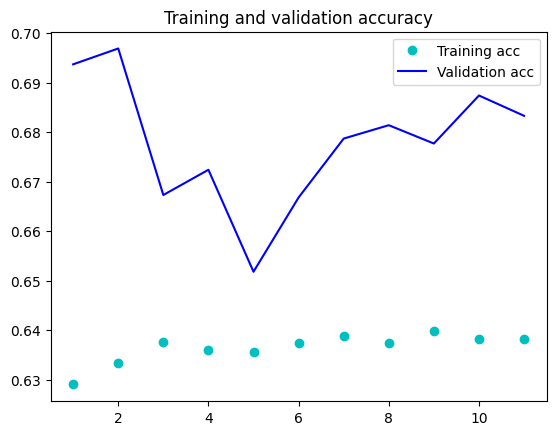

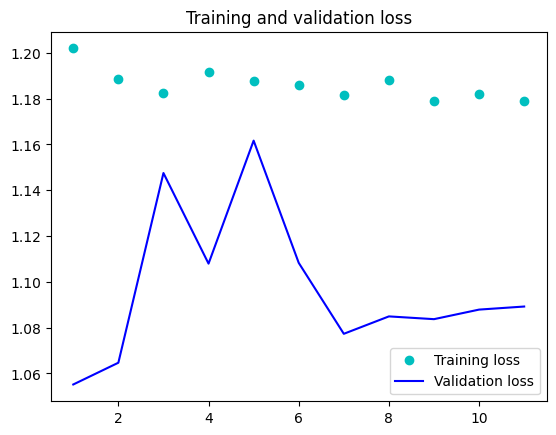

In [17]:
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'co', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'co', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

# validation acc e validation loss é a que realmente importa

Como referido em cima, de facto embora a accuracy de validação fosse superior à accuracy de treino, e à primeira vista parecesse que este modelo poderia melhorar mais, o mesmo não se mostrou verdade pois não houve melhoria de accuracy de validação.

In [18]:
val_loss, val_accuracy = model.evaluate(validation_dataset)
print(f'Validation Accuracy of the Best Model: {val_accuracy}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - acc: 0.6825 - loss: 1.0680
Validation Accuracy of the Best Model: 0.6937000155448914


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━

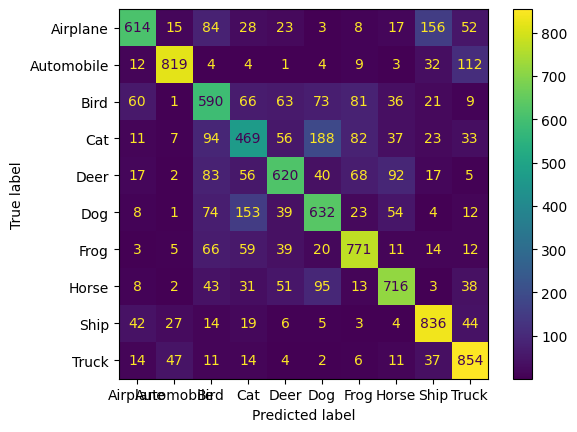

In [19]:
from sklearn import metrics


y_true = []
y_pred = []

# Iterate over the test dataset to get predictions and true labels
for images, labels in test_dataset:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Convert lists to NumPy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute the confusion matrix
conf_mat = metrics.confusion_matrix(y_true, y_pred)

# display matrix
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=["Airplane", "Automobile", "Bird", "Cat", "Deer", "Dog", "Frog", "Horse", "Ship", "Truck"])
cm_display.plot()
plt.show()


Por análise da matriz de confusão, entende-se que o modelo apresenta resultados maioritariamente satisfatórios, no entanto não tanto como o do modelo s com o RMSprop, com exceção de algumas classes que apresentam uma taxa de acerto menor. 
A destacar são as classes cat e bird, que são aquelas em que o modelo apresenta maior dificuldade em classificar corretamente, tendo em 1000 imagens acertado em 469 e 590, respetivamente. 
Outro ponto a destacar é que a classe pela qual 'cat' é mais confundida é a classe 'dog' e vice-versa, revelando que o modelo tem dificuldade em distinguir entre estas duas classes. 
Também há bastante confusão em distinguir airplane e ship, e automobile e truck. As classes com maior taxa de acerto são 'ship' e 'truck', com 836 e 854 imagens corretamente classificadas, respetivamente.

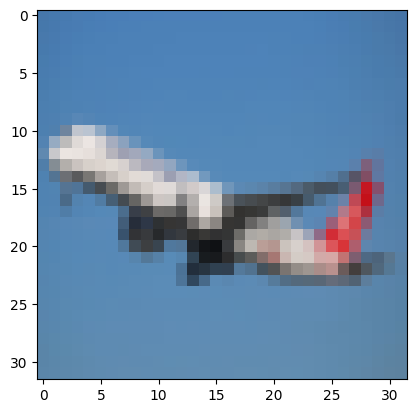

(1, 32, 32, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Model predicts:  airplane
Result:  [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [20]:
img = tf.keras.preprocessing.image.load_img('airplane.jpg', target_size=(32, 32), interpolation='bilinear')
plt.imshow(img)
plt.show()
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)
print(img_array.shape)
result = model.predict(img_array)
whatIsIt = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

predicted_classes = result.round()
predicted_index = np.where(predicted_classes == 1)[1]

print("Model predicts: ", whatIsIt[predicted_index[0]])
print("Result: ", result.round())